In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error,
    classification_report,
    confusion_matrix,
    fbeta_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef
)

In [56]:
train_path = "hf://datasets/mahmoudalyosify/SCRAP/train_data.csv"
df = pd.read_csv(train_path)
df.shape

(162634, 103)

In [57]:
df.head()

,event_id,time_to_tca,mission_id,risk,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,...,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP
0,0,1.566798,5,-10.204955,-7.834756,8.602101,14923.0,13792.0,453.8,5976.6,...,0.147350,58.272095,0.004092,0.165044,0.002987,0.386462,89.0,83.0,42.0,11.0
1,0,1.207494,5,-10.355758,-7.848937,8.956374,14544.0,13792.0,474.3,5821.2,...,0.059672,57.966413,0.003753,0.164383,0.002933,0.386393,89.0,83.0,42.0,11.0
2,0,0.952193,5,-10.345631,-7.847406,8.932195,14475.0,13792.0,474.6,5796.2,...,0.039258,57.907599,0.003576,0.164352,0.002967,0.386381,89.0,83.0,42.0,11.0
3,0,0.579669,5,-10.337809,-7.845880,8.913444,14579.0,13792.0,472.7,5838.9,...,0.022066,57.993905,0.003298,0.164309,0.002918,0.386400,89.0,83.0,40.0,14.0
4,0,0.257806,5,-10.391260,-7.852942,9.036838,14510.0,13792.0,478.7,5811.1,...,0.015075,57.946717,0.003670,0.164172,0.003220,0.386388,89.0,83.0,40.0,14.0


In [58]:
df_filtered = df[df['time_to_tca'] >= 2]
print("Shape after 2-day cutoff:", df_filtered.shape)

Shape after 2-day cutoff: (111939, 103)


In [59]:
data = df_filtered.copy()
data.shape

(111939, 103)

In [60]:
# Distribution of risk
risk_counts = data['risk'].value_counts()
risk_percent = data['risk'].value_counts(normalize=True) * 100

print("Risk Counts:")
print(risk_counts)

print("\nRisk Percentage:")
print(risk_percent)

# Check missing values
missing = data.isnull().sum()
missing = missing[missing > 0]

print("\nMissing Values:")
print(missing if len(missing) > 0 else "No missing values")

print("\nFirst 5 Rows:")
print(data.head())

Risk Counts:
risk
-30.000000    30287
-14.418050      790
-13.940815      545
-14.546835      515
-14.295592      257
              ...  
-8.037157         1
-7.062934         1
-7.215454         1
-7.108630         1
-7.066209         1
Name: count, Length: 55426, dtype: int64

Risk Percentage:
risk
-30.000000    27.056701
-14.418050     0.705742
-13.940815     0.486872
-14.546835     0.460072
-14.295592     0.229589
                ...    
-8.037157      0.000893
-7.062934      0.000893
-7.215454      0.000893
-7.108630      0.000893
-7.066209      0.000893
Name: proportion, Length: 55426, dtype: float64

Missing Values:
t_rcs_estimate            2204
t_crdot_r                 6125
t_crdot_t                 6125
t_crdot_n                 6125
t_ctdot_r                 6125
t_ctdot_t                 6125
t_ctdot_n                 6125
t_ctdot_rdot              6125
t_cndot_r                 6125
t_cndot_t                 6125
t_cndot_n                 6125
t_cndot_rdot              61

In [61]:
# Numeric columns
num_cols = data.select_dtypes(include=np.number).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Object / categorical columns
cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

print("Missing values after filling:", data.isnull().sum().sum())

Missing values after filling: 0


/var/folders/7_/t0fcm5gn1bzfty0fbmnh00h80000gn/T/ipykernel_57835/1497139020.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include='object').columns


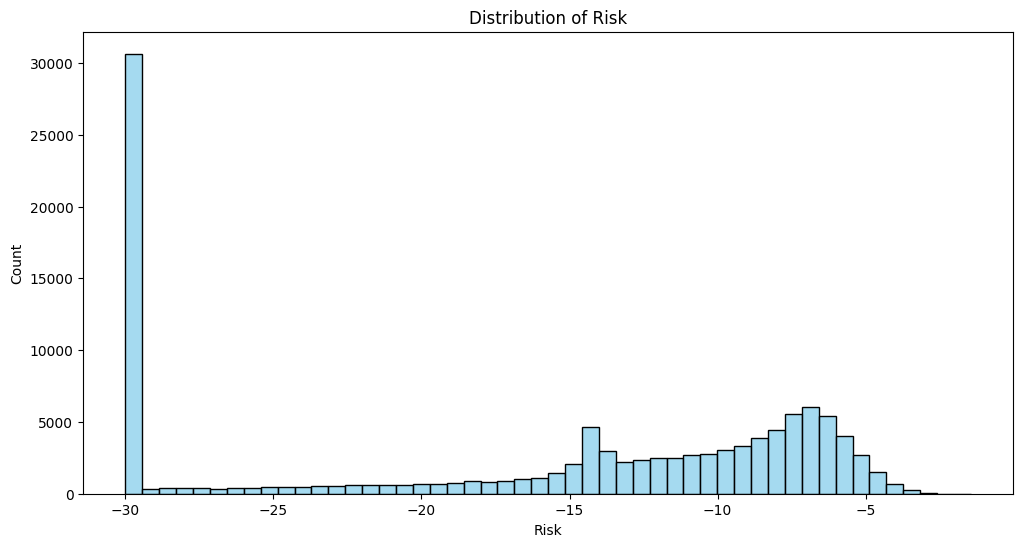

/var/folders/7_/t0fcm5gn1bzfty0fbmnh00h80000gn/T/ipykernel_57835/805942811.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.index.astype(str), y=top20.values, palette="viridis")


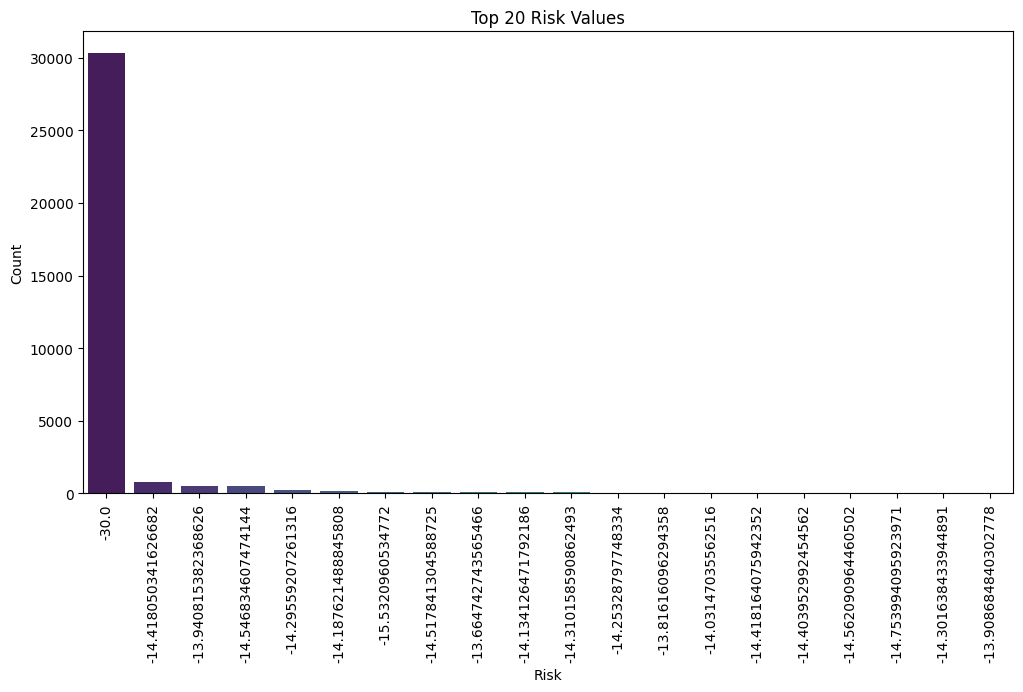

In [62]:
plt.figure(figsize=(12,6))
sns.histplot(data['risk'], bins=50, kde=False, color='skyblue')
plt.title("Distribution of Risk")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.show()

top20 = data['risk'].value_counts().head(20)
plt.figure(figsize=(12,6))
sns.barplot(x=top20.index.astype(str), y=top20.values, palette="viridis")
plt.title("Top 20 Risk Values")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [63]:
print("Risk Value Statistics:")
print(data['risk'].describe())

print("\nNumber of unique risk values:", data['risk'].nunique())

print("\nTop 10 most frequent risk values:")
print(data['risk'].value_counts().head(10))

print("\nBottom 10 least frequent risk values:")
print(data['risk'].value_counts().tail(10))

Risk Value Statistics:
count    111939.000000
mean        -16.542828
std           9.543314
min         -30.000000
25%         -30.000000
50%         -13.471984
75%          -7.942524
max          -1.442854
Name: risk, dtype: float64

Number of unique risk values: 55426

Top 10 most frequent risk values:
risk
-30.000000    30287
-14.418050      790
-13.940815      545
-14.546835      515
-14.295592      257
-14.187621      192
-15.532096      121
-14.517841      107
-13.664743      100
-14.134126       88
Name: count, dtype: int64

Bottom 10 least frequent risk values:
risk
-7.085868    1
-9.230623    1
-9.910095    1
-9.520281    1
-9.791559    1
-8.037157    1
-7.062934    1
-7.215454    1
-7.108630    1
-7.066209    1
Name: count, dtype: int64


In [64]:
bins = [-np.inf, -20, -10, np.inf]
labels = ['High', 'Medium', 'Low']

data['risk_bin'] = pd.cut(data['risk'], bins=bins, labels=labels)

print(data['risk_bin'].value_counts())
print("\nPercentage:")
print(data['risk_bin'].value_counts(normalize=True) * 100)

risk_bin
Low       40811
High      38563
Medium    32565
Name: count, dtype: int64

Percentage:
risk_bin
Low       36.458250
High      34.450013
Medium    29.091737
Name: proportion, dtype: float64


/var/folders/7_/t0fcm5gn1bzfty0fbmnh00h80000gn/T/ipykernel_57835/1333878792.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['risk_bin'] = pd.cut(data['risk'], bins=bins, labels=labels)


In [65]:
df_clean = data[['risk']].copy()
df_clean['risk_bin'] = pd.cut(df_clean['risk'], 
                              bins=[-np.inf, -20, -10, np.inf], 
                              labels=['High','Medium','Low'])

numeric_features = ['max_risk_estimate', 'max_risk_scaling', 'miss_distance', 'relative_speed']  # مثال
for col in numeric_features:
    df_clean[col] = data[col]

for col in numeric_features:
    stats = df_clean.groupby('risk_bin')[col].agg(['mean','std'])
    print(f"Feature: {col}")
    print(stats)
    print("-"*50)

Feature: max_risk_estimate
              mean       std
risk_bin                    
High     -6.418708  0.928277
Medium   -6.410716  0.962019
Low      -5.914253  1.000555
--------------------------------------------------
Feature: max_risk_scaling
                  mean            std
risk_bin                             
High      38755.952217  552630.246425
Medium       18.993612       9.251465
Low           4.922604       3.869905
--------------------------------------------------
Feature: miss_distance
                  mean           std
risk_bin                            
High      19385.658248  14839.758646
Medium    17262.381790  14407.434781
Low       13319.009605  12971.552983
--------------------------------------------------
Feature: relative_speed
                  mean          std
risk_bin                           
High      11031.916552  4293.892531
Medium    10615.794626  4372.247707
Low       10270.924016  4383.787192
-----------------------------------------------

In [66]:
num_cols = data.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['risk']]

# Compute skewness
skewed_feats = data[num_cols].apply(lambda x: skew(x.dropna()))
top_skewed = skewed_feats.sort_values(ascending=False).head(10)

print("Top 10 skewed numeric features:")
print(top_skewed)

Top 10 skewed numeric features:
t_time_lastob_start     74.783122
t_time_lastob_end       45.827178
max_risk_scaling        44.175475
c_cr_area_over_mass     18.555299
c_sedr                  17.730937
mahalanobis_distance    13.895305
c_cd_area_over_mass     12.755887
c_weighted_rms          12.076289
c_h_apo                 10.831929
c_j2k_sma               10.804960
dtype: float64


In [67]:
df_model = data.copy()

# Log transformation
for feat in top_skewed.index:
    if feat in df_model.columns:
        df_model[feat] = np.log1p(df_model[feat].abs()) * np.sign(df_model[feat])

print("Log transformation applied on top skewed features for the full dataset.")

Log transformation applied on top skewed features for the full dataset.


In [68]:
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

print("Columns after removing duplicates:")
print(df_model.columns.tolist())

y = df_model['risk_bin'].copy()
print("\ny type:", type(y))
print("y distribution:")
print(y.value_counts())

Columns after removing duplicates:
['event_id', 'time_to_tca', 'mission_id', 'risk', 'max_risk_estimate', 'max_risk_scaling', 'miss_distance', 'relative_speed', 'relative_position_r', 'relative_position_t', 'relative_position_n', 'relative_velocity_r', 'relative_velocity_t', 'relative_velocity_n', 't_time_lastob_start', 't_time_lastob_end', 't_recommended_od_span', 't_actual_od_span', 't_obs_available', 't_obs_used', 't_residuals_accepted', 't_weighted_rms', 't_rcs_estimate', 't_cd_area_over_mass', 't_cr_area_over_mass', 't_sedr', 't_j2k_sma', 't_j2k_ecc', 't_j2k_inc', 't_ct_r', 't_cn_r', 't_cn_t', 't_crdot_r', 't_crdot_t', 't_crdot_n', 't_ctdot_r', 't_ctdot_t', 't_ctdot_n', 't_ctdot_rdot', 't_cndot_r', 't_cndot_t', 't_cndot_n', 't_cndot_rdot', 't_cndot_tdot', 'c_object_type', 'c_time_lastob_start', 'c_time_lastob_end', 'c_recommended_od_span', 'c_actual_od_span', 'c_obs_available', 'c_obs_used', 'c_residuals_accepted', 'c_weighted_rms', 'c_rcs_estimate', 'c_cd_area_over_mass', 'c_cr_a

In [69]:
X = df_model.select_dtypes(include=np.number).copy()
y = df_model['risk_bin']  # Series

print("X shape:", X.shape)
print("y type:", type(y))
print("y distribution:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Handle NaN / Inf
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train.fillna(X_train.median(), inplace=True)
X_test.fillna(X_train.median(), inplace=True)

# Clip extreme values to avoid overflow
X_train = X_train.clip(-1e6, 1e6)
X_test = X_test.clip(-1e6, 1e6)

print("Any NaN left in X_train?", X_train.isna().sum().sum())
print("Any inf left in X_train?", np.isinf(X_train.values).sum())

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

balanced_acc = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
mcc = matthews_corrcoef(y_test, y_pred)
f2_weighted = fbeta_score(y_test, y_pred, beta=2, average='weighted')

print(f"\nBalanced Accuracy: {balanced_acc:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
print(f"Weighted F2-score: {f2_weighted:.4f}")

X shape: (111939, 102)
y type: <class 'pandas.Series'>
y distribution:
 risk_bin
Low       40811
High      38563
Medium    32565
Name: count, dtype: int64
Train size: (89551, 102)
Test size: (22388, 102)
Any NaN left in X_train? 0
Any inf left in X_train? 0

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7713
         Low       1.00      1.00      1.00      8162
      Medium       1.00      1.00      1.00      6513

    accuracy                           1.00     22388
   macro avg       1.00      1.00      1.00     22388
weighted avg       1.00      1.00      1.00     22388


Confusion Matrix:
[[7710    0    3]
 [   0 8162    0]
 [   0    0 6513]]

Balanced Accuracy: 0.9999
Macro F1-score: 0.9999
Matthews Correlation Coefficient (MCC): 0.9998
Weighted F2-score: 0.9999


In [70]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("classification report: ")
print(classification_report(y_test, y_pred))
print("confusion matrix: ")
print(confusion_matrix(y_test, y_pred))

classification report: 
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7713
         Low       1.00      1.00      1.00      8162
      Medium       1.00      1.00      1.00      6513

    accuracy                           1.00     22388
   macro avg       1.00      1.00      1.00     22388
weighted avg       1.00      1.00      1.00     22388

confusion matrix: 
[[7710    0    3]
 [   0 8162    0]
 [   0    0 6513]]


In [71]:
bin_to_numeric = {'Low': -20, 'Medium': -15, 'High': -5}

y_test_numeric = y_test.reset_index(drop=True).map(bin_to_numeric).astype(float)
y_pred_numeric = pd.Series(y_pred).reset_index(drop=True).map(bin_to_numeric).astype(float)

# F2 score (weighted)
f2 = fbeta_score(y_test.reset_index(drop=True), pd.Series(y_pred).reset_index(drop=True), beta=2, average='weighted')

# MSE
mse = mean_squared_error(y_test_numeric, y_pred_numeric)

# Custom loss
custom_loss = mse / f2

print("F2 Score:", f2)
print("MSE:", mse)
print("Custom Loss L(r, r_hat):", custom_loss)

F2 Score: 0.9998659937715145
MSE: 0.013400035733428623
Custom Loss L(r, r_hat): 0.013401831662344491
